# Discontinuous Galerkin on triangles

Upwind DG for linear advection, the vertex-based limiter, and the shallow water equations with a Rusanov flux. The manual has the details in Section 12.9.

In [1]:
import numpy as np, femd as fd, time
import matplotlib.pyplot as plt
pi = np.pi

## 1. Periodic advection: convergence at rate k + 1

$u_t + \nabla\cdot(\mathbf b u) = 0$ on the doubly periodic unit square, with the upwind flux written in the form language.

In [2]:
def advection(V, b):
    u, v, n = fd.TrialFunction(V), fd.TestFunction(V), fd.FacetNormal()
    bv = fd.as_vector(list(b))
    bn = fd.dot(bv, n('-'))
    return fd.form(u * fd.dot(bv, fd.grad(v)) * fd.dx
                   - (bn * fd.avg(u) + 0.5 * fd.abs(bn) * fd.jump(u)) * fd.jump(v) * fd.dS)

b = np.array([1.0, 0.5])
u0 = lambda x, y: np.sin(2 * pi * x) * np.sin(2 * pi * y)
T = 0.25
for k in (1, 2):
    prev = None
    for n in (8, 16, 32):
        m = fd.rectangle_mesh(0, 0, 1, 1, n, n)
        V = fd.DGSpace(m, k, periodic=[(4, 2), (1, 3)])
        u, v = fd.TrialFunction(V), fd.TestFunction(V)
        N = int(np.ceil(T / (0.1 / n / (2 * k + 1))))
        w = fd.Function(V, V.project(u0))
        rk = fd.SSPRK(fd.form(u * v * fd.dx), advection(V, b), T / N, order=3)
        for _ in range(N):
            rk.step(w)
        Q = V.cache(2 * k + 4)
        X, Y, wq = np.asarray(Q.x()), np.asarray(Q.y()), np.asarray(Q.weights())
        e = np.sqrt(np.sum(wq * (V.at_quad(Q, w.vector, 0) - u0(X - b[0] * T, Y - b[1] * T)) ** 2))
        print(f"P{k}  {n:2d} x {n:2d}   L2 error {e:.2e}" + ("" if prev is None else f"   rate {np.log2(prev / e):.2f}"))
        prev = e

P1   8 x  8   L2 error 3.09e-02
P1  16 x 16   L2 error 7.96e-03   rate 1.96
P1  32 x 32   L2 error 2.00e-03   rate 1.99


P2   8 x  8   L2 error 3.38e-03
P2  16 x 16   L2 error 4.34e-04   rate 2.96


P2  32 x 32   L2 error 5.48e-05   rate 2.99


## 2. A discontinuous profile, with and without the vertex-based limiter

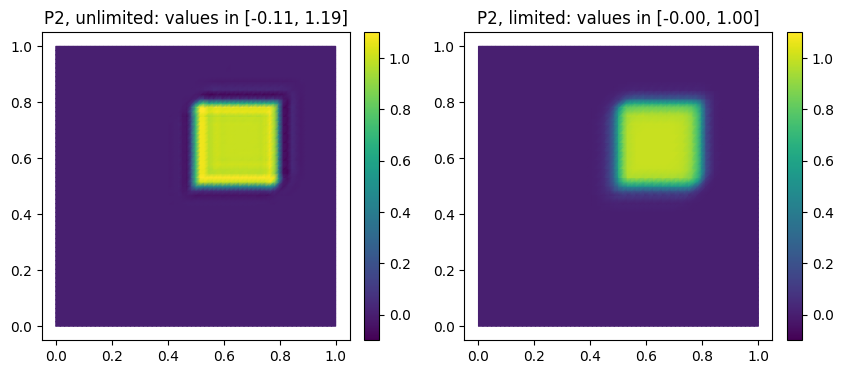

In [3]:
sq = lambda x, y: ((np.abs(x - 0.35) < 0.15) & (np.abs(y - 0.5) < 0.15)).astype(float)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, limit in zip(axes, (False, True)):
    m = fd.rectangle_mesh(0, 0, 1, 1, 32, 32)
    V = fd.DGSpace(m, 2, periodic=[(4, 2), (1, 3)])
    u, v = fd.TrialFunction(V), fd.TestFunction(V)
    lim = fd.VertexLimiter(V) if limit else None
    w = fd.Function(V, V.interpolate(sq))
    if lim:
        lim(w)
    dt = 0.1 / 32 / 5
    rk = fd.SSPRK(fd.form(u * v * fd.dx), advection(V, b), dt, order=3, limiter=lim)
    for _ in range(int(0.3 / dt)):
        rk.step(w)
    V.plot(w, ax=ax, vmin=-0.1, vmax=1.1)
    vals = V.at_quad(V.cache(6), w.vector, 0)
    ax.set_title(f"P2, {'limited' if limit else 'unlimited'}: values in [{vals.min():.2f}, {vals.max():.2f}]")

## 3. Shallow water: the dam break against Stoker's solution

$U = (h, hu, hv)$, a local Lax-Friedrichs (Rusanov) flux, reflecting walls, SSPRK3 with the vertex-based limiter on all three fields.

50 x 5: 133 steps in 1.0 s, L1 error of h 0.116


100 x 10: 266 steps in 6.8 s, L1 error of h 0.060


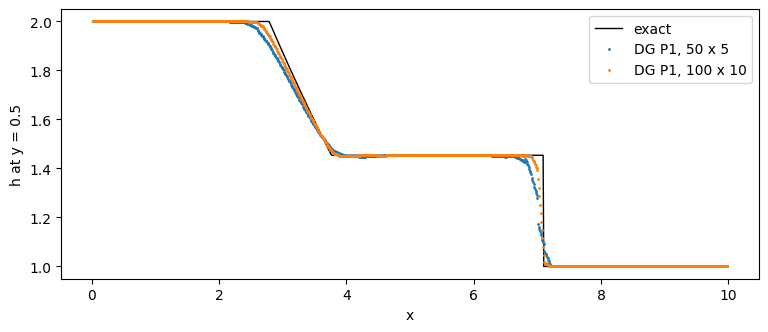

In [4]:
g = 9.81

def shallow_water(m, k=1):
    Q = fd.DGSpace(m, k)
    W = fd.ProductSpace(Q, Q, Q)
    w = fd.Function(W)
    h, hu, hv = w
    tests = fd.TestFunctions(W)
    n = fd.FacetNormal()
    p = 0.5 * g * h * h
    F = [fd.as_vector([hu, hv]), fd.as_vector([hu * hu / h + p, hu * hv / h]), fd.as_vector([hv * hu / h, hv * hv / h + p])]
    nm = n('-')
    lam = lambda s: fd.abs((hu(s) * nm[0] + hv(s) * nm[1]) / h(s)) + fd.sqrt(g * h(s))
    alpha = fd.max_value(lam('-'), lam('+'))
    R = fd.form(sum(fd.dot(Fi, fd.grad(vi)) for Fi, vi in zip(F, tests)) * fd.dx
                - sum((fd.dot(fd.avg(Fi), nm) + 0.5 * alpha * fd.jump(Ui)) * fd.jump(vi)
                      for Fi, Ui, vi in zip(F, (h, hu, hv), tests)) * fd.dS
                - p * (n[0] * tests[1] + n[1] * tests[2]) * fd.ds)
    M = fd.form(sum(a * c for a, c in zip(fd.TrialFunctions(W), tests)) * fd.dx)
    return Q, W, w, M, R

def stoker(x, t, hL=2.0, hR=1.0, x0=5.0):
    cL = np.sqrt(g * hL)
    f = lambda hs: 2 * (cL - np.sqrt(g * hs)) - (hs - hR) * np.sqrt(0.5 * g * (1 / hs + 1 / hR))
    a, c = hR, hL
    for _ in range(100):
        mid = 0.5 * (a + c)
        a, c = (mid, c) if f(mid) > 0 else (a, mid)
    hs = 0.5 * (a + c); us = 2 * (cL - np.sqrt(g * hs)); S = hs * us / (hs - hR)
    xi = (x - x0) / t
    return np.where(xi <= -cL, hL, np.where(xi <= us - np.sqrt(g * hs), (2 * cL - xi) ** 2 / (9 * g), np.where(xi <= S, hs, hR)))

T = 0.5
plt.figure(figsize=(9, 3.5))
xs = np.linspace(0.02, 9.98, 1000)
plt.plot(xs, stoker(xs, T), "k-", lw=1, label="exact")
for nx in (50, 100):
    m = fd.rectangle_mesh(0, 0, 10, 1, nx, nx // 10)
    Q, W, w, M, R = shallow_water(m)
    w.interpolate([lambda x, y: np.where(x < 5.0, 2.0, 1.0), 0.0, 0.0])
    lim = fd.VertexLimiter(W); lim(w)
    N = int(np.ceil(T / (0.25 * (10 / nx) / (np.sqrt(2 * g) * 3))))
    rk = fd.SSPRK(M, R, T / N, order=3, limiter=lim)
    t0 = time.time()
    for _ in range(N):
        rk.step(w)
    hh = w.split()[0]
    Qc = Q.cache(4); X, wq = np.asarray(Qc.x()), np.asarray(Qc.weights())
    L1 = np.sum(wq * np.abs(Q.at_quad(Qc, hh.vector, 0) - stoker(X, T)))
    print(f"{nx} x {nx // 10}: {N} steps in {time.time() - t0:.1f} s, L1 error of h {L1:.3f}")
    plt.plot(xs, hh.at(np.column_stack([xs, np.full_like(xs, 0.5)])), ".", ms=2, label=f"DG P1, {nx} x {nx // 10}")
plt.xlabel("x"); plt.ylabel("h at y = 0.5"); plt.legend();

## 4. A circular dam break

The same residual on a square, with a column of water in the middle. The solution keeps the symmetry of the mesh up to the diagonals.

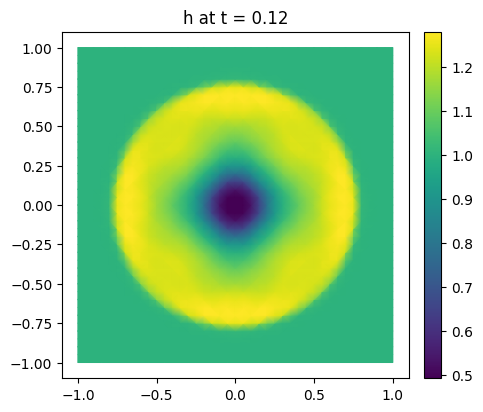

In [5]:
m = fd.rectangle_mesh(-1, -1, 1, 1, 40, 40, diagonal="alternate")
Q, W, w, M, R = shallow_water(m)
w.interpolate([lambda x, y: np.where(x * x + y * y < 0.3 ** 2, 2.0, 1.0), 0.0, 0.0])
lim = fd.VertexLimiter(W); lim(w)
T = 0.12
N = int(np.ceil(T / (0.25 * 0.05 / (np.sqrt(2 * g) * 3))))
rk = fd.SSPRK(M, R, T / N, order=3, limiter=lim)
for _ in range(N):
    rk.step(w)
hh = w.split()[0]
fig, ax = plt.subplots(figsize=(5, 4.5))
Q.plot(hh, ax=ax)
ax.set_title(f"h at t = {T}");